# 06 — `FreqGainChanger`: random per-band gain in the frequency domain

Splits the input into `n_bands` non-overlapping frequency bands
(via `julius.bands.split_bands`), applies a softmax-normalised
random gain per band each forward pass, recombines.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

import scitex_nn

torch.manual_seed(0)
fs, seq_len, n_bands, n_runs = 256, 1024, 4, 8

x = torch.randn(1, 1, seq_len)
fg = scitex_nn.FreqGainChanger(n_bands=n_bands, samp_rate=fs).train()
psd_layer = scitex_nn.PSD(sample_rate=fs)
psd_orig, freqs = psd_layer(x.squeeze())
freqs = freqs.numpy()

## Many runs of the augmentation, overlay PSDs

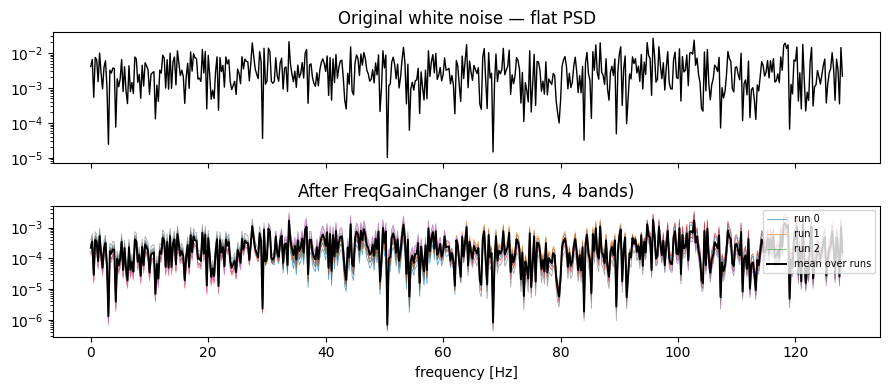

In [2]:
runs = np.stack([psd_layer(fg(x.clone()).squeeze())[0].numpy() for _ in range(n_runs)])

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
axes[0].plot(freqs, psd_orig.numpy(), "k", lw=1.0)
axes[0].set_yscale("log")
axes[0].set_title("Original white noise — flat PSD")

for i, m in enumerate(runs):
    axes[1].plot(freqs, m, lw=0.6, alpha=0.7, label=f"run {i}" if i < 3 else None)
axes[1].plot(freqs, runs.mean(0), "k", lw=1.4, label="mean over runs")
axes[1].set_yscale("log")
axes[1].legend(loc="upper right", fontsize=7)
axes[1].set_xlabel("frequency [Hz]")
axes[1].set_title(f"After FreqGainChanger ({n_runs} runs, {n_bands} bands)")
fig.tight_layout()
plt.show()